# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [768]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from nonlocal_correlations import *

In [769]:

annotation_names = {'LGR5': '0.C02.percentile99_class', 
                    'Chromogranin A': '0.C03.percentile99_class', 
                    'Cyclin D': '0.C04.percentile99_class', 
                    'Mucin 2': '1.C03.percentile99_class', 
                    'AldoB': '1.C04.percentile99_class', 
                    'Glucagon': '2.C02.percentile99_class', 
                    'Cyclin A': '2.C03.percentile99_class', 
                    'Agr2': '2.C04.percentile99_class', 
                    'Serotonin': '3.C02.percentile99_class', 
                    'Lysozyme': '3.C03.percentile99_class', 
                    }

def extract_markers(m, annotation_names):
    """
    Extract reference positional field and standardized marker fields.

    Parameters
    ----------
    m : object
        Object with attributes:
          - m.fields: ndarray of shape (N, num_fields)
          - m.field_names: list of field name strings, length = num_fields
    annotation_names : dict
        Mapping from human-readable marker name -> field_name in m.field_names

    Returns
    -------
    ref_field : (N,) ndarray
        Reference positional field (from "4.label").
    markers_array : (N, M) ndarray
        Array of marker intensities in standardized order.
    marker_names : list of str
        Human-readable marker names in the same order as markers_array.
    """

    field_names = list(m.field_names)

    # --- 1. Extract reference positional field (4.label) ---
    if "4.label" not in field_names:
        raise ValueError("Reference field '4.label' not found in m.field_names")
    ref_idx = field_names.index("4.label")
    ref_field = m.fields[:, ref_idx]

    # --- 2. Extract markers in standardized order ---
    markers_list = []
    marker_names = []

    for name, fname in annotation_names.items():
        if fname not in field_names:
            raise ValueError(f"Marker field '{fname}' for '{name}' not found in m.field_names")
        idx = field_names.index(fname)
        markers_list.append(m.fields[:, idx])
        marker_names.append(name)

    markers_array = np.column_stack(markers_list)  # shape (N, M)

    return ref_field, markers_array, marker_names


## Load organoid mesh and build laplacian

For illustration purposes we just treat a single organoid 

In [ ]:
data_dir = '../NicoleData/20250929/fractal_output'

# choose one timepoint/well/round
# timepoint = "day4p5-more" # "day4p5"
# zarr_name = "r0.zarr"
# well = "C01" # "A06"
# round_name = "0_fused_zillum_registered"
# organoid_id = 14  # 19 # example

timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "A06"
round_name = "0_fused_zillum_registered"
organoid_id = 19 # example

path = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_multi_annotated_class/{organoid_id}.vtp"


m = FateMarkers()
m.load_mesh_from_file(path)
m.align_with_pca()
_ = m.compute_coefficients(lmax=15)    # must populate m.eigvals, m.eigvecs
L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

print(m.v.shape)

(18000, 3)


In [771]:
hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=False)
print(hks.shape)

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=hks,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Heat kernel signature"
)

fig.show()

(18000, 1)


In [772]:
print(m.field_names)


ref_field, markers_array, marker_names = extract_markers(m, annotation_names)


vertex_fields = np.concatenate([hks, markers_array], axis=1)
field_names = ["HKS"] + marker_names

print(field_names)

plot_idx = 8
fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=markers_array[:,plot_idx],
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title=marker_names[plot_idx],
)

fig.show()

['4.label', '2.label', '2.C02.percentile99_class', '2.C03.percentile99_class', '2.C04.percentile99_class', '0.label', '0.C02.percentile99_class', '0.C03.percentile99_class', '0.C04.percentile99_class', '1.label', '1.C03.percentile99_class', '1.C04.percentile99_class', '3.label', '3.C02.percentile99_class', '3.C03.percentile99_class']
['HKS', 'LGR5', 'Chromogranin A', 'Cyclin D', 'Mucin 2', 'AldoB', 'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


Additionally we calculate the Voronoi area weight per vertex, which can be done directly from the mass matrix

In [773]:
vertex_areas = np.array(M.diagonal())


# for comparison compute face areas directly
tri = m.v[m.f]
face_areas = 0.5 * np.linalg.norm(np.cross(tri[:,1] - tri[:,0], tri[:,2] - tri[:,0]), axis=1)

total_face_area = face_areas.sum()
total_vertex_area = vertex_areas.sum()

print("Total face area:   ", total_face_area)
print("Total vertex area: ", total_vertex_area)

Total face area:    204.6946
Total vertex area:  204.69461723334416


## Coarse-grain to cell-level

To limit the computations needed for calculating correlations, we coarse-grain the vertex mesh, selecting the surface centroid of each cell. Additionally, we compute some quantities averaged over the surface area of each cell.

Note, for computing geodesic distances between the coarse-grained points, we still need the full mesh.

In [774]:
def get_patch_centers(vertices, labels):
    """
    For each patch (unique label), compute the 'center' vertex index:
      - compute centroid of all vertices in patch
      - pick vertex in patch closest to this centroid
    
    Args:
        vertices: (V,3) ndarray of vertex coordinates
        labels: (V,) ndarray of integer patch labels
    
    Returns:
        unique_labels: (P,) ndarray of sorted unique labels
        centers_idx: (P,) ndarray of vertex indices (into vertices)
    """
    unique_labels = np.unique(labels)
    centers_idx = np.empty(len(unique_labels), dtype=int)

    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        patch_vertices = vertices[mask]

        # centroid of patch vertices
        centroid = patch_vertices.mean(axis=0)

        # indices of patch vertices in global array
        patch_indices = np.nonzero(mask)[0]

        # find vertex closest to centroid
        diffs = vertices[patch_indices] - centroid
        dists = np.einsum("ij,ij->i", diffs, diffs)  # squared distances
        best_idx = patch_indices[np.argmin(dists)]

        centers_idx[i] = best_idx

    return unique_labels, centers_idx

In [775]:
def remap_labels_to_contiguous(labels):
    """
    labels: (V,) int array, may contain negative -1 for unlabeled vertices.
    returns:
      labels_contig: (V,) ints in -1 or [0..C-1]
      mapping: dict old_label -> new_index
    """
    labs = np.asarray(labels)
    uniq = np.unique(labs[labs >= 0])
    mapping = {int(old): new for new, old in enumerate(uniq)}
    labels_contig = np.full_like(labs, -1)
    for old, new in mapping.items():
        labels_contig[labs == old] = new
    return labels_contig, mapping


def per_cell_stats_from_vertex_labels(v, f, vertex_areas, vertex_cell_labels, vertex_fields):
    # remap labels first
    labels, mapping = remap_labels_to_contiguous(vertex_cell_labels)
    V = v.shape[0]
    vf = np.asarray(vertex_fields)
    if vf.ndim == 1:
        vf = vf[:, None]
    C = int(labels.max() + 1) if (labels >= 0).any() else 0

    weighted_pos = np.zeros((C, 3), dtype=float)
    weighted_field = np.zeros((C, vf.shape[1]), dtype=float)
    cell_area_v = np.zeros(C, dtype=float)
    counts = np.zeros(C, dtype=int)

    for idx in range(V):
        lab = int(labels[idx])
        if lab < 0:
            continue
        a = float(vertex_areas[idx])
        weighted_pos[lab] += a * v[idx]
        weighted_field[lab] += a * vf[idx]
        cell_area_v[lab] += a
        counts[lab] += 1

    valid = cell_area_v > 0
    centroids = np.zeros((C, 3), dtype=float)
    fields = np.zeros((C, vf.shape[1]), dtype=float)
    centroids[valid] = weighted_pos[valid] / cell_area_v[valid, None]
    fields[valid] = weighted_field[valid] / cell_area_v[valid, None]

    return centroids, cell_area_v, fields, valid, labels

In [776]:

_, patch_centers = get_patch_centers(m.v, ref_field)

centroids, cell_areas, cell_weighted_fields, valid, cell_labels = per_cell_stats_from_vertex_labels(m.v, m.f, vertex_areas, ref_field, vertex_fields)

print(patch_centers.shape)  # {label: vertex_index}
print(centroids.shape)

V = m.v.shape[0]
S = patch_centers.shape[0] # subset size 

(302,)
(302, 3)


In [777]:
fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=ref_field,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    ),
    go.Scatter3d(
        # x=centroid_coords[:,0], y=centroid_coords[:,1], z=centroid_coords[:,2],
        x=m.v[patch_centers,0], y=m.v[patch_centers,1], z=m.v[patch_centers,2],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name="Source vertex"
    ),
    go.Scatter3d(
        # x=centroid_coords[:,0], y=centroid_coords[:,1], z=centroid_coords[:,2],
        x=centroids[:,0], y=centroids[:,1], z=centroids[:,2],
        mode='markers',
        marker=dict(size=6, color='blue', symbol='circle'),
        name="Centroid coordinates"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Patch centers"
)

fig.show()


## Calculate geodesics

In [778]:
# Calculate geodesics using heat method (Crane et al. 2013)
dist_heat_all = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)

heat sources: 100%|██████████| 302/302 [00:01<00:00, 170.16it/s]


In [779]:
# For comparison we calculate distances with Dijkstra
edge_graph = build_edge_graph(m.v, m.f)
dist_graph_all = geodesic_dijkstra_all_sources(edge_graph, sources=patch_centers)

In [780]:
# select just the subset pairs
dist_heat = dist_heat_all[:, patch_centers] # (S,S)
dist_graph = dist_graph_all[:, patch_centers]

# get upper upper triangle (i<j, no duplicate vertex pairs) and flatten into vector 
iu, ju = np.triu_indices(S, k=1)
d_heat_pairs =  dist_heat[iu, ju]
d_graph_pairs = dist_graph[iu, ju]


print(dist_heat_all.shape)
print(dist_heat.shape)
print(d_heat_pairs.shape)

(302, 18000)
(302, 302)
(45451,)


Plotting the geodesic distances vs graph distances, shows similar distribution but the latter having larger values. This is to be expected, as Dijkstra calculates cummulative distance through the edges, while the heat method approximates the geodesics.

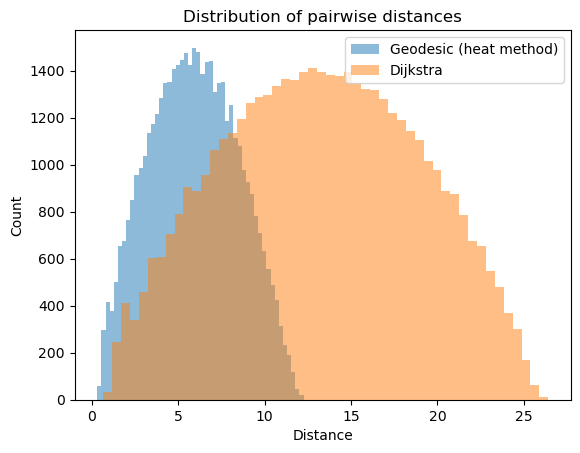

In [781]:
plt.hist(d_heat_pairs, bins=50, alpha=0.5, label="Geodesic (heat method)")
plt.hist(d_graph_pairs, bins=50, alpha=0.5, label="Dijkstra")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of pairwise distances")
plt.show()

As a sanity check, we can plot the distance to a single point for both methods. Given the size of the organoid, it should be evident that Dijkstra gives way too large values.

In [782]:
src_idx = 42  # single heat source

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=dist_heat_all[src_idx, :],
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    ),
    go.Scatter3d(
        x=[m.v[patch_centers[src_idx],0]], y=[m.v[patch_centers[src_idx],1]], z=[m.v[patch_centers[src_idx],2]],
        mode='markers',
        marker=dict(size=6, color='red', symbol='circle'),
        name="Source vertex"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Geodesic distances (Heat method)"
)

fig.show()


## Calculate 2-point correlation functions

The distances obtained with the heat method are binned, then correlations are computed for each bin 

In [783]:
# --- binning parameters ---
dmax = 0.99*np.max(d_heat_pairs)
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

bins_dist_weighted = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=True)
bins_dist_equal = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)


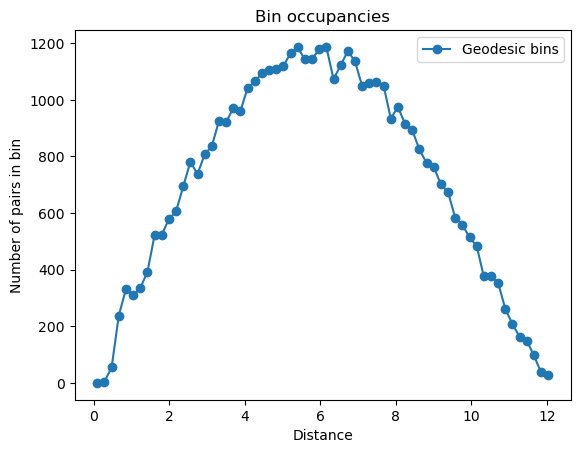

In [784]:
counts_dist = [len(bins_dist_weighted[f"I_{b}"]) for b in range(len(bin_edges)-1)]

plt.plot(bin_centers, counts_dist, 'o-', label="Geodesic bins")
plt.xlabel("Distance")
plt.ylabel("Number of pairs in bin")
plt.legend()
plt.title("Bin occupancies")
plt.show()

## Calculate correlations on cell grid

The first step is to figure out the correct normalization for the fields and the correlations. 

Let bin $b$ contain unordered pairs $(i,j)$, with $i < j$, chosen such that the geodesic distance $d(i,j)$ lies within the range of the bin. The two-point correlation of fields $F^k$ and $F^l$ can then be calculated within a given bin using:

**Surface-integral (area-weighted) approach**
$$ C_b^{k l} = Z_b^{-1} \sum_{(i,j)\in r} a_i a_j F_i^k F_j^l$$
where $Z_b = \sum_{(i,j)\in r} a_i a_j$ and $a_i$ is the surface area of surface area associated to sample $i$.


**Lattice (equal-weight) approach**
$$ C_b^{k l} = N_b^{-1} \sum_{(i,j)\in r}  F_i^k F_j^l$$
where $N_b$ is the number of unordered pairs in bin $b$.


If cell areas are nonuniform, the lattice estimator equals the area-weighted estimator only if either
1. $a_i \approx \mathrm{const}$ (which is the case for fate markers), or
2. the field $\mathbf{F}$ is uncorrelated with $\mathbf{a}$ (i.e. the distribution of $\mathbf{F}$ is independent of cell area)
Otherwise the lattice estimator is a biased approximation to the surface integral.


** Connected correlations**
The raw two-point correlation C_b^{kl} contains both genuine correlations and a trivial baseline from the global means.  
To isolate fluctuations, we define the connected correlation:

$$C_{b,conn}^{kl} = C_b^{kl} - \mu^k \mu^l $$

with global means

- Surface (area-weighted): $\mu^k = (\sum_i a_i F_i^k) / (\sum_i a_i)$  
- Lattice (equal-weight): $\mu^k = (1/V) \sum_i F_i^k $

Normalization difference:  
- Raw C_b^{kl} is normalized per-bin (Z_b or N_b).  
- The subtraction uses global means, independent of bin.  

Thus, uncorrelated fields yield C_{b,conn}^{kl} ≈ 0, while any nontrivial spatial structure remains visible.


**In this section**

To determine which approach is best, we run a few tests:

1. Compare area-weighted and equal-weighted correlation for **synthetic fields**
2. Compare for the **physical fields** (here just for a single organoid)


### Generate synthetic scalar field for correlation testing

In [785]:
def generate_sinusoidal_field(v: np.ndarray, k: float = 5.0, direction: np.ndarray = None) -> np.ndarray:
    """
    Generate a synthetic sinusoidal scalar field on a mesh.
    
    Args:
        v : ndarray (V,3)
            Vertex coordinates.
        k : float
            Wavenumber. Higher k = shorter wavelength.
        direction : ndarray (3,), optional
            Direction vector along which to define the sinusoid.
            Defaults to x-axis.
    
    Returns:
        field : ndarray (V,)
            Scalar field values at each vertex.
    """
    if direction is None:
        direction = np.array([1.0, 0.0, 0.0])
    direction = direction / np.linalg.norm(direction)
    
    # Project vertices onto direction
    proj = v @ direction
    # Sine wave along that direction
    field = np.sin(k * proj)
    return field


def generate_gaussian_bump_field(v: np.ndarray, center_idx: int = 0, sigma: float = 0.1) -> np.ndarray:
    """
    Generate a localized Gaussian bump field on the mesh.
    
    Args:
        v : ndarray (V,3)
            Vertex coordinates.
        center_idx : int
            Index of vertex to use as Gaussian center.
        sigma : float
            Width (standard deviation) of the Gaussian in Euclidean space.
    
    Returns:
        field : ndarray (V,)
            Scalar field values at each vertex.
    """
    center = v[center_idx]
    dists = np.linalg.norm(v - center[None,:], axis=1)
    field = np.exp(-0.5 * (dists / sigma)**2)
    return field


In [786]:
# Generate a synthetic test field on the organoid
field_sin = generate_sinusoidal_field(m.v, k=3.0)        # sinusoidal
field_gauss = generate_gaussian_bump_field(m.v, center_idx=500, sigma=6.0) # Gaussian bump


fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=field_sin,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Synthetic field for correlation testing"
)

fig.show()

In [787]:
X = np.stack([field_sin[patch_centers], field_gauss[patch_centers]], axis=1)  # shape (V,2)

# Accumulate correlations
Cw_synth, Nw_synth = accumulate_correlations_from_bins(bins_dist_weighted, X) # compute surface area weighted correlations
Ce_synth, Ne_synth = accumulate_correlations_from_bins(bins_dist_equal, X) # compute equal weighted correlations

print(Cw_synth.shape)
print(Nw_synth.shape)

(64, 2, 2)
(64,)


In [788]:
# Number of fields (F)
F = Cw_synth.shape[1]

# --- compute means ---
# For equal-weight (lattice) use simple arithmetic mean over cells
mean_eq = np.nanmean(X, axis=0)   # shape (F,)

# For weighted (surface) means we use cell_areas if available
areas = np.asarray(cell_areas, dtype=float)
A_sum = np.sum(areas)
if A_sum <= 0:
    raise ValueError("cell_areas sum is zero or negative")
mean_w = (areas[:, None] * X).sum(axis=0) / A_sum


# --- subtract mean outer product to get connected correlations ---
def connected_from_C(C, mean_vec):
    """
    C: (B,F,F)
    mean_vec: (F,)
    returns C_conn: (B,F,F)
    """
    B = C.shape[0]
    C_conn = np.empty_like(C)
    mm = np.outer(mean_vec, mean_vec)  # (F,F)
    for b in range(B):
        if np.all(np.isnan(C[b])):
            C_conn[b] = np.full((F,F), np.nan)
        else:
            C_conn[b] = C[b] - mm
    return C_conn

Cw_synth_conn = connected_from_C(Cw_synth, mean_w)
Ce_synth_conn = connected_from_C(Cw_synth, mean_eq)

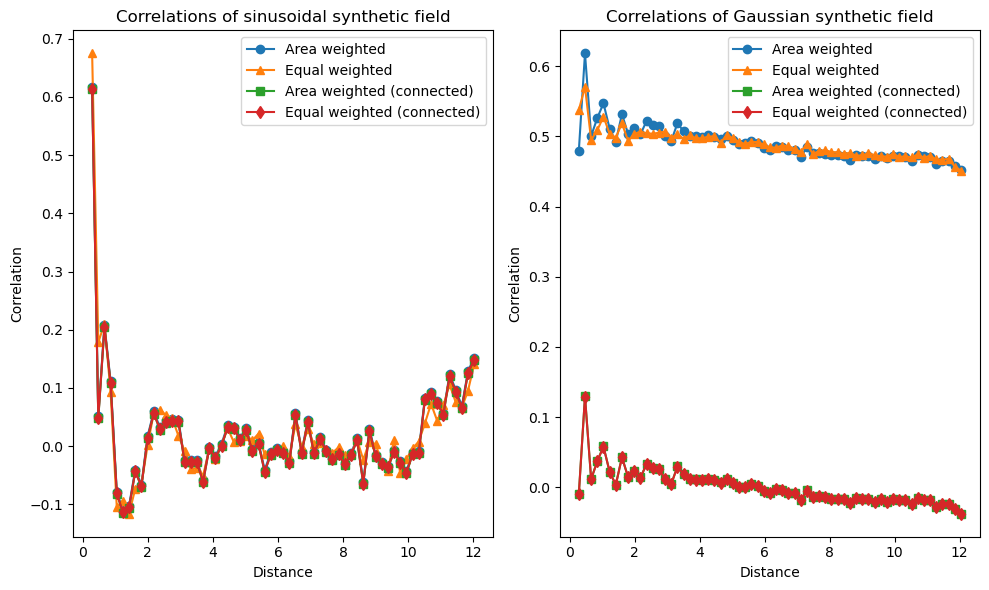

In [789]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.plot(bin_centers, Cw_synth[:,0,0], 'o-', label="Area weighted")
plt.plot(bin_centers, Ce_synth[:,0,0], '^-', label="Equal weighted")
plt.plot(bin_centers, Cw_synth_conn[:,0,0], 's-', label="Area weighted (connected)")
plt.plot(bin_centers, Ce_synth_conn[:,0,0], 'd-', label="Equal weighted (connected)")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Correlations of sinusoidal synthetic field")
plt.legend()

plt.subplot(1,2,2)
plt.plot(bin_centers, Cw_synth[:,1,1], 'o-', label="Area weighted")
plt.plot(bin_centers, Ce_synth[:,1,1], '^-', label="Equal weighted")
plt.plot(bin_centers, Cw_synth_conn[:,1,1], 's-', label="Area weighted (connected)")
plt.plot(bin_centers, Ce_synth_conn[:,1,1], 'd-', label="Equal weighted (connected)")
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Correlations of Gaussian synthetic field")
plt.legend()

plt.tight_layout()
plt.show()

### Auto-correlation of HKS

In [790]:
hks_raw = vertex_fields[patch_centers, 0] # raw value of HKS sampled at cell centroids
hks_cell = cell_weighted_fields[:, 0] # HKS weighted over the area of each cell

print(hks_raw.shape)
print(hks_cell.shape)

(302,)
(302,)


In [791]:
Cw_hks_raw, Nw_hks_raw = accumulate_correlations_from_bins(bins_dist_weighted, hks_raw) # compute surface area weighted correlations
Ce_hks_raw, Ne_hks_raw = accumulate_correlations_from_bins(bins_dist_equal, hks_raw) # compute equal weighted correlations

Cw_hks_cell, Nw_hks_cell = accumulate_correlations_from_bins(bins_dist_weighted, hks_cell) # compute surface area weighted correlations
Ce_hks_cell, Ne_hks_cell = accumulate_correlations_from_bins(bins_dist_equal, hks_cell) # compute equal weighted correlations

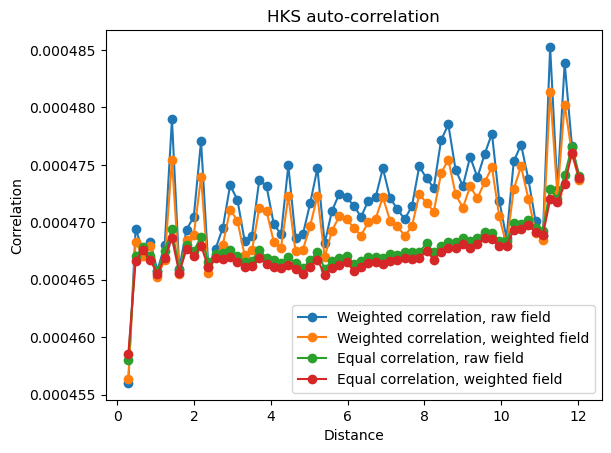

In [792]:
plt.plot(bin_centers, Cw_hks_raw[:,0,0], 'o-', label="Weighted correlation, raw field")
plt.plot(bin_centers, Cw_hks_cell[:,0,0], 'o-', label="Weighted correlation, weighted field")

plt.plot(bin_centers, Ce_hks_raw[:,0,0], 'o-', label="Equal correlation, raw field")
plt.plot(bin_centers, Ce_hks_cell[:,0,0], 'o-', label="Equal correlation, weighted field")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation")
plt.legend()


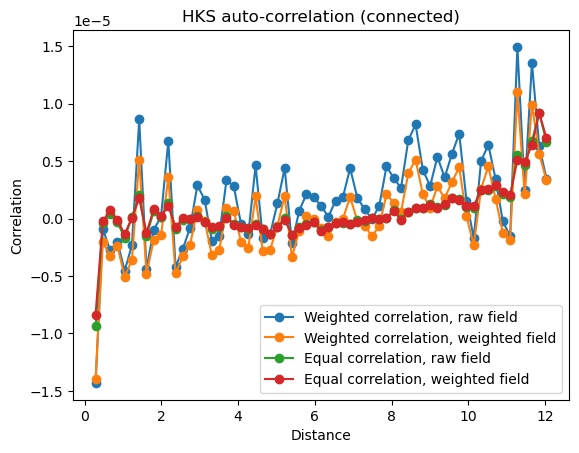

In [793]:
# If your HKS arrays are V-length vectors, make them (V,1)
def ensure_field_matrix(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X[:, None]
    return X

# The per-cell HKS arrays used when building the Cs:
# - hks_raw: HKS sampled at centroids (shape (C,) or (C,1))
# - hks_cell: HKS averaged over cell patch (shape (C,) or (C,1))
hks_raw_m = ensure_field_matrix(hks_raw)
hks_cell_m = ensure_field_matrix(hks_cell)

# Number of fields (F)
F = Cw_hks_raw.shape[1]

# --- compute means ---
# For equal-weight (lattice) use simple arithmetic mean over cells
mean_eq_raw = np.nanmean(hks_raw_m, axis=0)   # shape (F,)
mean_eq_cell = np.nanmean(hks_cell_m, axis=0)

# For weighted (surface) means we use cell_areas if available
if 'cell_areas' in globals() or 'cell_areas' in locals():
    areas = np.asarray(cell_areas, dtype=float)
    A_sum = np.sum(areas)
    if A_sum <= 0:
        raise ValueError("cell_areas sum is zero or negative")
    mean_w = (areas[:, None] * hks_raw_m).sum(axis=0) / A_sum
    mean_w = (areas[:, None] * hks_cell_m).sum(axis=0) / A_sum
else:
    # Fallback: use arithmetic mean if no areas provided,
    # but this is not strictly area-weighted!
    mean_w = mean_eq_raw.copy()
    mean_w = mean_eq_cell.copy()
    print("Warning: cell_areas not found; using arithmetic mean for weighted means (not ideal).")

# --- subtract mean outer product to get connected correlations ---
def connected_from_C(C, mean_vec):
    """
    C: (B,F,F)
    mean_vec: (F,)
    returns C_conn: (B,F,F)
    """
    B = C.shape[0]
    C_conn = np.empty_like(C)
    mm = np.outer(mean_vec, mean_vec)  # (F,F)
    for b in range(B):
        if np.all(np.isnan(C[b])):
            C_conn[b] = np.full((F,F), np.nan)
        else:
            C_conn[b] = C[b] - mm
    return C_conn

Cw_hks_raw_conn = connected_from_C(Cw_hks_raw, mean_w)
Ce_hks_raw_conn = connected_from_C(Ce_hks_raw, mean_eq_raw)
Cw_hks_cell_conn = connected_from_C(Cw_hks_cell, mean_w)
Ce_hks_cell_conn = connected_from_C(Ce_hks_cell, mean_eq_cell)


plt.plot(bin_centers, Cw_hks_raw_conn[:,0,0], 'o-', label="Weighted correlation, raw field")
plt.plot(bin_centers, Cw_hks_cell_conn[:,0,0], 'o-', label="Weighted correlation, weighted field")

plt.plot(bin_centers, Ce_hks_raw_conn[:,0,0], 'o-', label="Equal correlation, raw field")
plt.plot(bin_centers, Ce_hks_cell_conn[:,0,0], 'o-', label="Equal correlation, weighted field")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation (connected)")
plt.legend()

### Auto- and cross-correlations of all fields

Since the centroid-sampled and cell-area-averaged fields seem very similar, we proceed just using the former

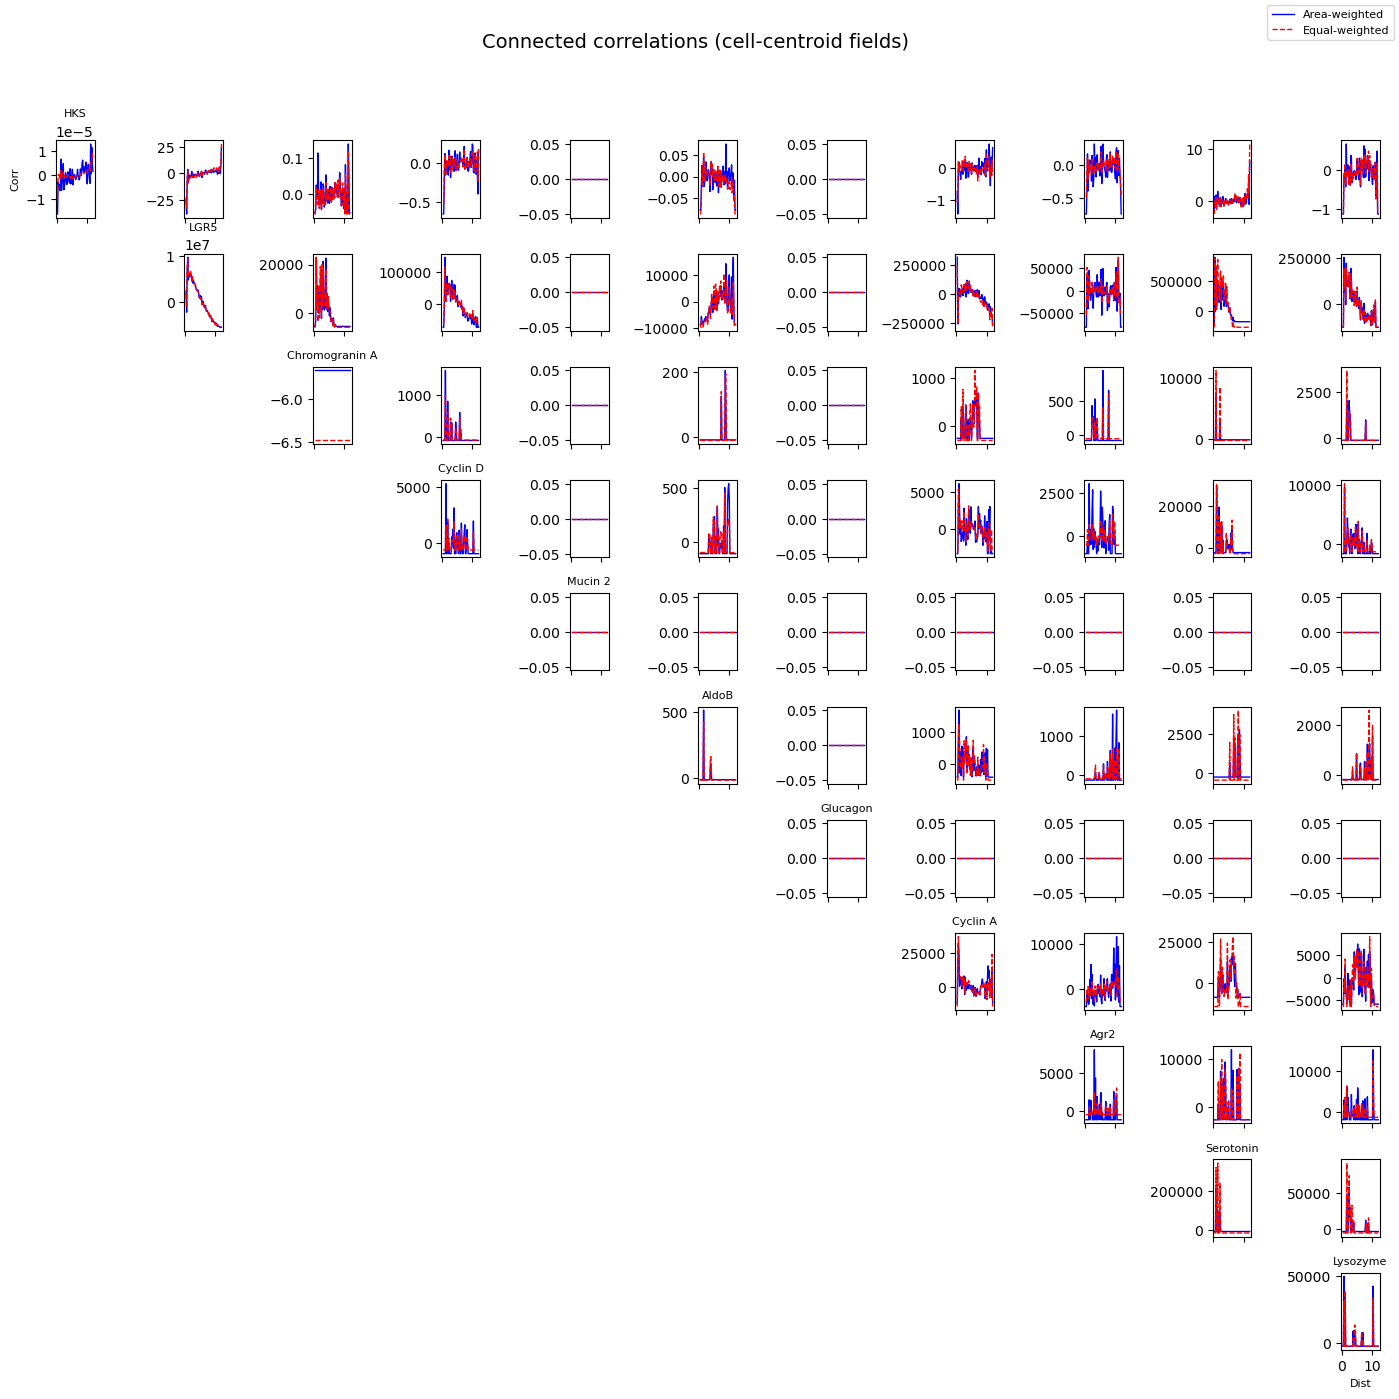

In [794]:
X = vertex_fields[patch_centers, :]

Cw_raw, Nw_raw = accumulate_correlations_from_bins(bins_dist_weighted, X) # compute surface area weighted correlations
Ce_raw, Ne_raw = accumulate_correlations_from_bins(bins_dist_equal, X) # compute equal weighted correlations


# --- compute connected correlations ---
F = X.shape[1]

# Global means (equal-weighted)
mean_eq = np.mean(X, axis=0)

# Area-weighted means (using cell areas)
mean_w = (cell_areas[:, None] * X).sum(axis=0) / areas.sum()

# Connected correlations: subtract global mean products
Cw_raw_conn = np.copy(Cw_raw)
Ce_raw_conn = np.copy(Ce_raw)

for b in range(len(Nw_raw)):
    if Nw_raw[b] > 0:
        Cw_raw_conn[b] -= np.outer(mean_w, mean_w)
    else:
        Cw_raw_conn[b] = np.full((F, F), np.nan)

for b in range(len(Ne_raw)):
    if Ne_raw[b] > 0:
        Ce_raw_conn[b] -= np.outer(mean_eq, mean_eq)
    else:
        Ce_raw_conn[b] = np.full((F, F), np.nan)

# --- plotting ---
B, F, _ = Cw_raw_conn.shape

fig, axes = plt.subplots(F, F, figsize=(14, 14), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # plot both weighted and equal-weighted
        ax.plot(bin_centers, Cw_raw_conn[:, i, j], 'b-', lw=1, label="Area-weighted" if (i==0 and j==0) else "")
        ax.plot(bin_centers, Ce_raw_conn[:, i, j], 'r--', lw=1, label="Equal-weighted" if (i==0 and j==0) else "")

        # ax.plot(bin_centers, Cw_raw[:, i, j], 'b-', lw=1, label="Area-weighted" if (i==0 and j==0) else "")
        # ax.plot(bin_centers, Ce_raw[:, i, j], 'r--', lw=1, label="Equal-weighted" if (i==0 and j==0) else "")

        # Label diagonals with field names
        if i == j:
            ax.set_title(field_names[i], fontsize=8)

        # Only left column gets y-labels
        if j == 0:
            ax.set_ylabel("Corr", fontsize=8)

        # Only bottom row gets x-labels
        if i == F-1:
            ax.set_xlabel("Dist", fontsize=8)

# Global labels + legend
fig.suptitle("Connected correlations (cell-centroid fields)", fontsize=14)
fig.legend(loc="upper right", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



## Subtracting spherical mode

In [795]:
def zero_low_l_modes(coeffs, l_cut):
    """
    Zero out coefficients for modes with spherical-harmonic band index ell <= l_cut.
    coeffs: (K, F)
    returns: coeffs_clean (K, F)
    """
    K, F = coeffs.shape
    coeffs_clean = coeffs.copy()
    # modes m with ell satisfying ell^2 <= m <= (ell+1)^2 - 1 for ell = 0..l_cut inclusive
    max_m = min(K, (l_cut+1)**2)  # upper bound (exclusive)
    if max_m <= 0:
        return coeffs_clean
    coeffs_clean[:max_m, :] = 0.0
    return coeffs_clean

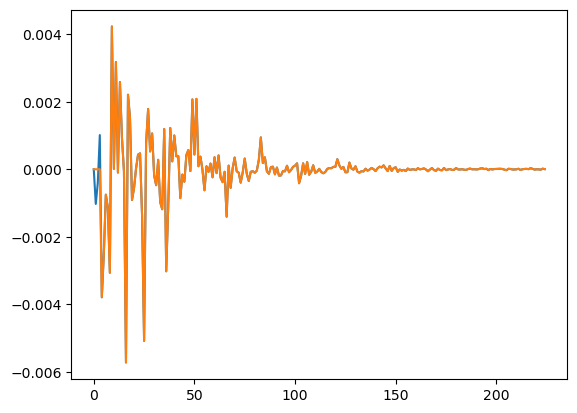

In [796]:
hks_coeffs = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=True)
hks_coeffs_cut0 = zero_low_l_modes(hks_coeffs, 0)
hks_coeffs_cut1 = zero_low_l_modes(hks_coeffs, 1)

plt.plot(hks_coeffs_cut0)
plt.plot(hks_coeffs_cut1)

In [797]:
hks_cut0 = m.reconstruct_from_coeffs(hks_coeffs_cut0, lmax=15)
hks_cut1 = m.reconstruct_from_coeffs(hks_coeffs_cut1, lmax=15)

fig = go.Figure(data=[
    go.Mesh3d(
        x=m.v[:,0], y=m.v[:,1], z=m.v[:,2],
        i=m.f[:,0], j=m.f[:,1], k=m.f[:,2],
        intensity=hks_cut1,
        colorscale='Viridis',
        showscale=True,   # adds colorbar
        name="Surface"
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    title="Heat kernel signature with low spectral modes removed"
)

fig.show()

In [798]:
# C_hks_cut0, N_hks_cut0 = accumulate_correlations_from_bins(bins_dist_equal, hks_cut0) # compute equal weighted correlations
# C_hks_cut1, N_hks_cut1 = accumulate_correlations_from_bins(bins_dist_equal, hks_cut1) # compute equal weighted correlations


# mean_eq_cut0 = np.nanmean(hks_cut0, axis=0)   # shape (F,)
# mean_eq_cut1 = np.nanmean(hks_cut1, axis=0)   # shape (F,)
# C_hks_cut0_conn = connected_from_C(C_hks_cut0, mean_eq_cut0)
# C_hks_cut1_conn = connected_from_C(C_hks_cut1, mean_eq_cut1)

# plt.figure(figsize=(10,5))

# plt.subplot(1,3,1)
# plt.plot(bin_centers, Ce_hks_raw_conn[:,0,0], 'o-', label="All modes")
# plt.xlabel("Distance")
# plt.ylabel("Correlation")
# plt.legend()

# plt.subplot(1,3,2)
# plt.plot(bin_centers, C_hks_cut0_conn[:,0,0], '^-', label="l<=0 removed")
# plt.xlabel("Distance")
# plt.ylabel("Correlation")
# plt.legend()

# plt.subplot(1,3,3)
# plt.plot(bin_centers, C_hks_cut1_conn[:,0,0], '^-', label="l<=1 removed")
# plt.xlabel("Distance")
# plt.ylabel("Correlation")
# plt.legend()

# plt.tight_layout()
# plt.show()

# Anchored correlation functions

In [799]:
def pair_bins_from_sources(D: np.ndarray,
                           areas: np.ndarray,
                           bin_edges: np.ndarray,
                           sources: np.ndarray,
                           use_area_weights: bool = True):
    """
    Construct pair bins (i,j) where i is restricted to a source set.

    Args
    ----
    D : (N,N) ndarray
        Symmetric distance matrix (vertex/cell geodesic distances).
    areas : (N,) ndarray
        Weights per element (vertex areas, cell patch areas, etc).
    bin_edges : (B+1,) ndarray
        Distance bin edges.
    sources : (S,) ndarray of int
        Indices of source elements (e.g. serotonin+ cells).
    use_area_weights : bool
        If True, pair weights = area[i]*area[j].
        If False, weights = 1.

    Returns
    -------
    bins_dict : dict
        For each bin b:
          - I_b : indices of sources in pairs
          - J_b : indices of partner elements
          - W_b : weights for each pair
        Plus 'bin_edges'.
    """
    N = D.shape[0]
    B = len(bin_edges) - 1
    r_max = bin_edges[-1]

    I_bins = [[] for _ in range(B)]
    J_bins = [[] for _ in range(B)]
    W_bins = [[] for _ in range(B)]

    for i in sources:
        ds = D[i, :]
        js = np.arange(N)

        mask = (ds <= r_max) & (js != i)  # exclude self
        if not np.any(mask):
            continue

        ds2 = ds[mask]
        js = js[mask]
        bins = np.searchsorted(bin_edges, ds2, side='right') - 1
        valid = (bins >= 0) & (bins < B)
        bins = bins[valid]
        js = js[valid]

        if use_area_weights:
            w = areas[i] * areas[js]
        else:
            w = np.ones_like(js, dtype=np.float32)

        for b, j, wb in zip(bins, js, w):
            I_bins[b].append(i)
            J_bins[b].append(int(j))
            W_bins[b].append(float(wb))

    out = {'bin_edges': np.asarray(bin_edges)}
    for b in range(B):
        out[f'I_{b}'] = np.asarray(I_bins[b], dtype=np.int32)
        out[f'J_{b}'] = np.asarray(J_bins[b], dtype=np.int32)
        out[f'W_{b}'] = np.asarray(W_bins[b], dtype=np.float32)
    return out


In [800]:
def positive_indices_and_labels(X: np.ndarray):
    """
    For each column of X, return the row indices of positive entries,
    and a binary (0/1) mask of the same shape as X.
    
    Parameters
    ----------
    X : np.ndarray
        Input array (2D or higher, but column logic applies to last axis).
    
    Returns
    -------
    indices_per_col : list of np.ndarray
        List of arrays, where indices_per_col[j] contains the row indices
        of positive entries in column j.
    labels : np.ndarray
        Binary mask of the same shape as X (1 if >0, else 0).
    """
    # binary mask (0/1)
    labels = (X > 0).astype(int)
    
    # handle only the first two axes for "rows" and "columns"
    indices_per_col = [np.where(labels[:, j])[0] for j in range(X.shape[1])]
    
    return indices_per_col, labels


In [801]:
cell_fields = vertex_fields[patch_centers, :]
positive_indices, positive_labels = positive_indices_and_labels(cell_fields)

print(positive_indices[1]) # Seratonin
print(positive_indices[2]) # Lysozyme
print(positive_indices[0]) # HKS (should regurn all)



[ 49  50  59  63  64  68  70  71  76  77  81  83  85  86  90  91  94 103
 106 110 111 112 113 117 118 119 122 124 125 128 132 135 136 137 141 144
 147 151 153 154 158 159 161 162 164 169 170 172 175 178 180 182 183 185
 186 190 196 197 201 202 203 204 206 207 208 209 211 212 217 220 221 222
 224 225 226 227 233 236 237 241 242 243 244 245 246 250 251 253 254 257
 258 259 260 261 262 263 264 265 268 269 270 271 272 273 275 278 279 280
 281 282 283 285 286 287 288 290 291 292 293 294 295 296 297 298 299 300
 301]
[273]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 11

In [802]:
bins_dist_sources_seratonin = pair_bins_from_sources(dist_heat, cell_areas, bin_edges, positive_indices[8], use_area_weights=False)
bins_dist_sources_lysozyme = pair_bins_from_sources(dist_heat, cell_areas, bin_edges, positive_indices[9], use_area_weights=False)

C_sera, N_sera = accumulate_correlations_from_bins(bins_dist_sources_seratonin, cell_fields) # compute equal weighted correlations
C_lyso, N_lyso = accumulate_correlations_from_bins(bins_dist_sources_lysozyme, cell_fields) # compute equal weighted correlations

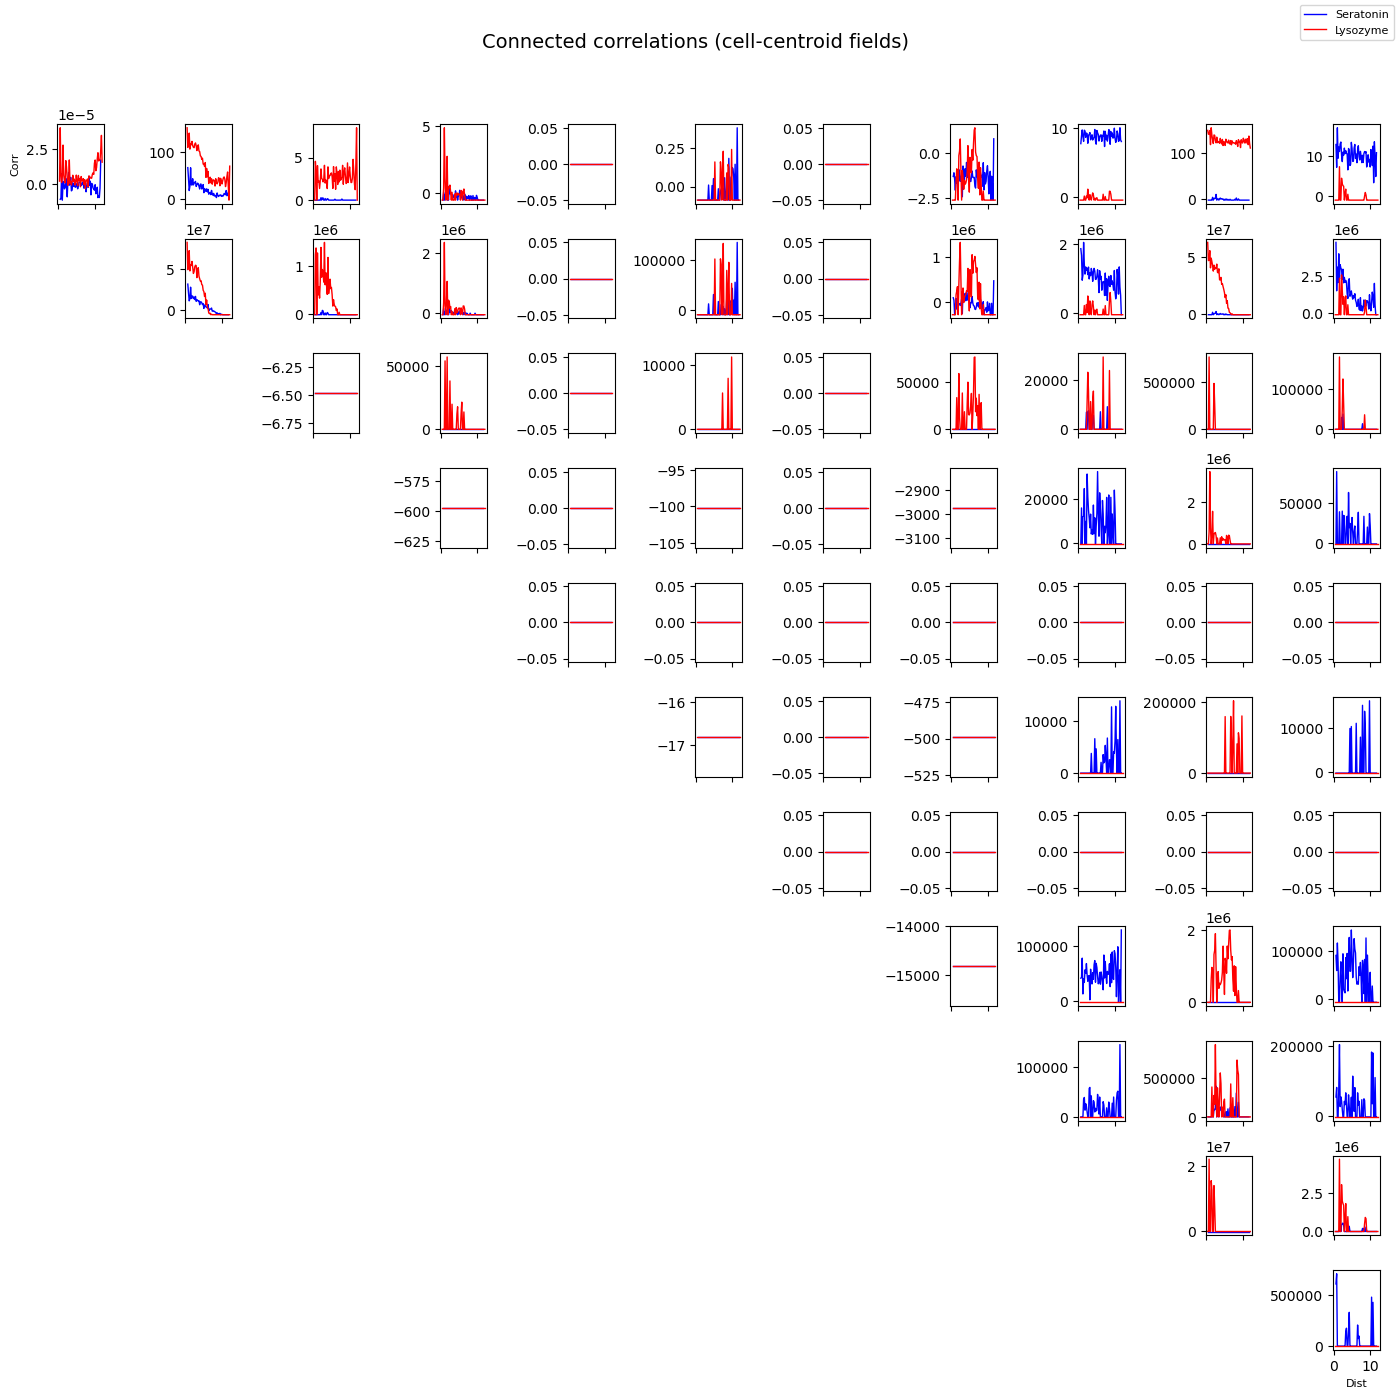

In [803]:
# --- compute connected correlations ---
F = cell_fields.shape[1]

# Global means (equal-weighted)
mean_eq = np.mean(cell_fields, axis=0)

def connected_correlations(C, N, mean_eq):
    """Compute connected correlations for one correlation set."""
    C_conn = np.copy(C)
    for b in range(len(N)):
        if N[b] > 0:
            C_conn[b] -= np.outer(mean_eq, mean_eq)
        else:
            C_conn[b] = np.full((F, F), np.nan)
    return C_conn

C_sera_conn = connected_correlations(C_sera, N_sera, mean_eq)
C_lyso_conn = connected_correlations(C_lyso, N_lyso, mean_eq)

# --- plotting ---
B, F, _ = C_sera_conn.shape  # assumes same shape for both

fig, axes = plt.subplots(F, F, figsize=(14, 14), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # plot connected correlations for both sera and lyso
        ax.plot(bin_centers, C_sera_conn[:, i, j], 'b-', lw=1,
                label="Seratonin" if (i == 0 and j == 0) else "")
        ax.plot(bin_centers, C_lyso_conn[:, i, j], 'r-', lw=1,
                label="Lysozyme" if (i == 0 and j == 0) else "")

        # Label diagonals with field names
        # if i == j:
        #     ax.set_title(field_names[i], fontsize=8)

        # Only left column gets y-labels
        if j == 0:
            ax.set_ylabel("Corr", fontsize=8)

        # Only bottom row gets x-labels
        if i == F - 1:
            ax.set_xlabel("Dist", fontsize=8)

# Global labels + legend
fig.suptitle("Connected correlations (cell-centroid fields)", fontsize=14)
fig.legend(loc="upper right", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [804]:
def binary_seed_enrichment(bins_dict: dict,
                           binary_labels: np.ndarray):
    """
    Compute seed-anchored enrichment of binary-labeled cells.

    Args
    ----
    bins_dict : dict
        Output from pair_bins_from_sources. Must contain:
        - I_b, J_b, W_b for each bin
        - 'bin_edges'
    binary_labels : (N,) or (N,M) array of int or bool
        0/1 array indicating whether each cell expresses the marker(s).
        If 2D, each column is treated as a separate marker.

    Returns
    -------
    enrichment : (B,M) array
        Enrichment values E(r) = f_local(r) / f_global for each distance bin.
    f_local : (B,M) array
        Weighted local fraction of positives per bin.
    f_global : (M,) array
        Weighted global fraction of positives across all cells.
    bin_centers : (B,) array
        Midpoints of the distance bins.
    Ns : (B,) array
        Effective weighted counts (sum of weights) per bin.
    """
    bin_edges = bins_dict['bin_edges']
    B = len(bin_edges) - 1

    # Ensure labels are 2D: (N, M)
    if binary_labels.ndim == 1:
        binary_labels = binary_labels[:, None]
    N, M = binary_labels.shape

    f_local = np.zeros((B, M), dtype=np.float64)
    Ns = np.zeros(B, dtype=np.float64)

    # Compute local fractions in each bin
    for b in range(B):
        J_b = bins_dict[f'J_{b}']
        W_b = bins_dict[f'W_{b}']
        if len(J_b) == 0:
            continue

        lbls = binary_labels[J_b, :]   # (len(J_b), M)
        w = W_b[:, None]               # (len(J_b), 1)

        Ns[b] = np.sum(W_b)
        if Ns[b] > 0:
            f_local[b, :] = np.sum(w * lbls, axis=0) / Ns[b]

    # Global fractions, weighted by areas (since areas are in weights)
    total_w = np.zeros((N,), dtype=np.float64)
    for b in range(B):
        J_b = bins_dict[f'J_{b}']
        W_b = bins_dict[f'W_{b}']
        for j, w in zip(J_b, W_b):
            total_w[j] += w

    denom = np.sum(total_w)
    if denom > 0:
        f_global = (total_w[:, None] * binary_labels).sum(axis=0) / denom
    else:
        f_global = np.full(M, np.nan)

    # Enrichment
    enrichment = np.divide(f_local, f_global[None, :],
                           out=np.full_like(f_local, np.nan),
                           where=f_global[None, :] > 0)

    # Bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return enrichment, f_local, f_global, bin_centers, Ns


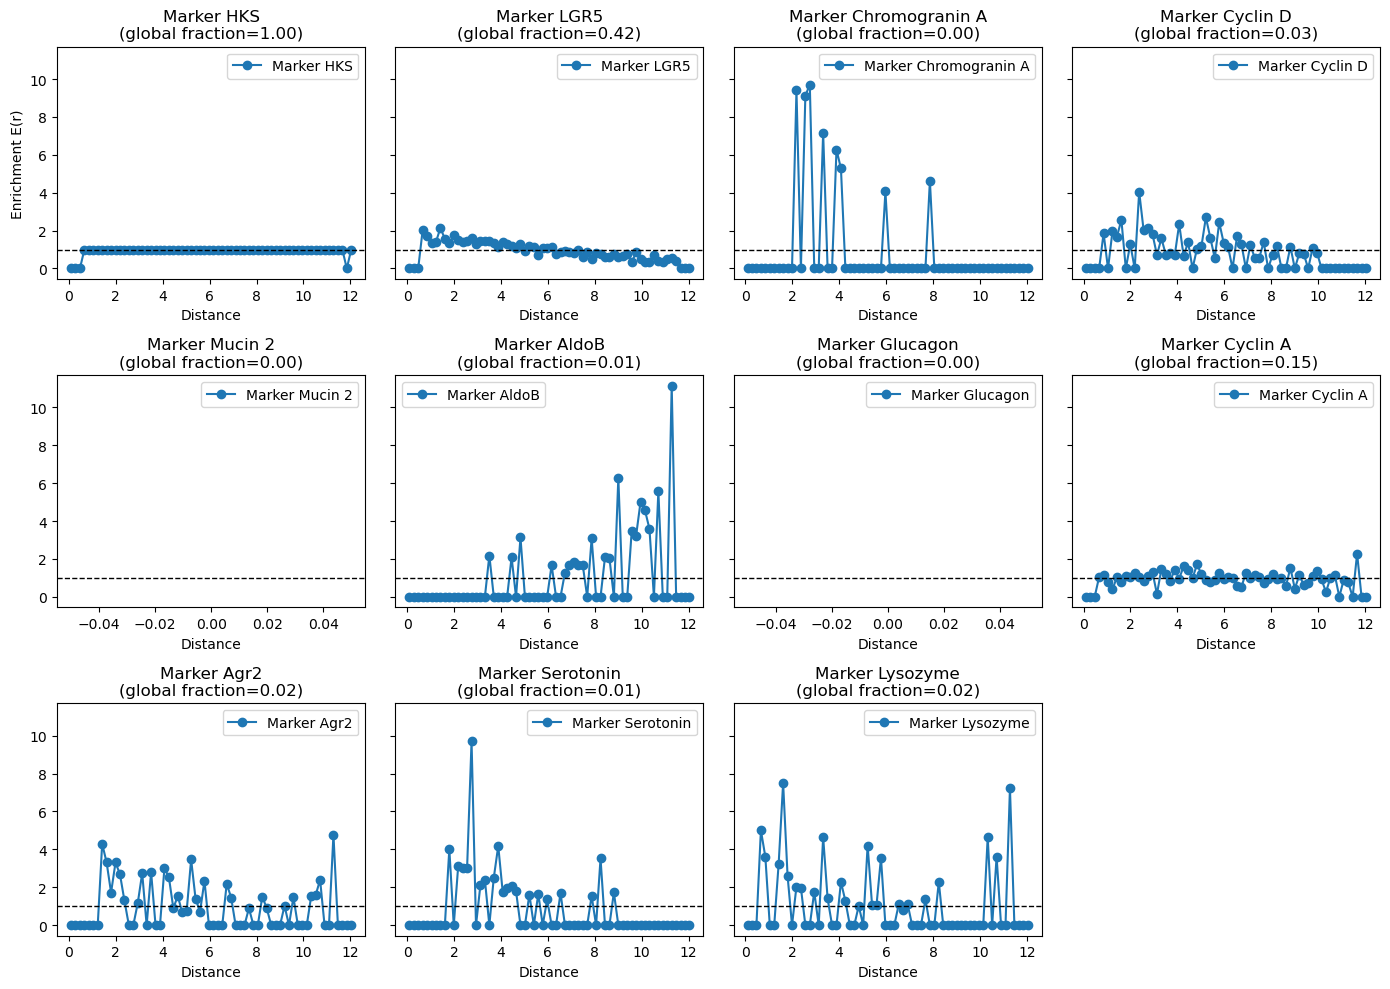

In [805]:
enrichment_sera, f_local_sera, f_global_sera, bin_centers, Ns_sera = binary_seed_enrichment(bins_dist_sources_seratonin, positive_labels)

F = enrichment_sera.shape[1]  # number of markers
nrows = int(np.ceil(F / 4))

fig, axes = plt.subplots(nrows, 4, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i in range(F):
    ax = axes[i]
    ax.plot(bin_centers, enrichment_sera[:, i], marker="o", label=f"Marker {field_names[i]}")
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("Distance")
    if i == 0:
        ax.set_ylabel("Enrichment E(r)")
    ax.set_title(f"Marker {field_names[i]}\n(global fraction={f_global_sera[i]:.2f})")
    ax.legend()

# hide unused axes
for j in range(F, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



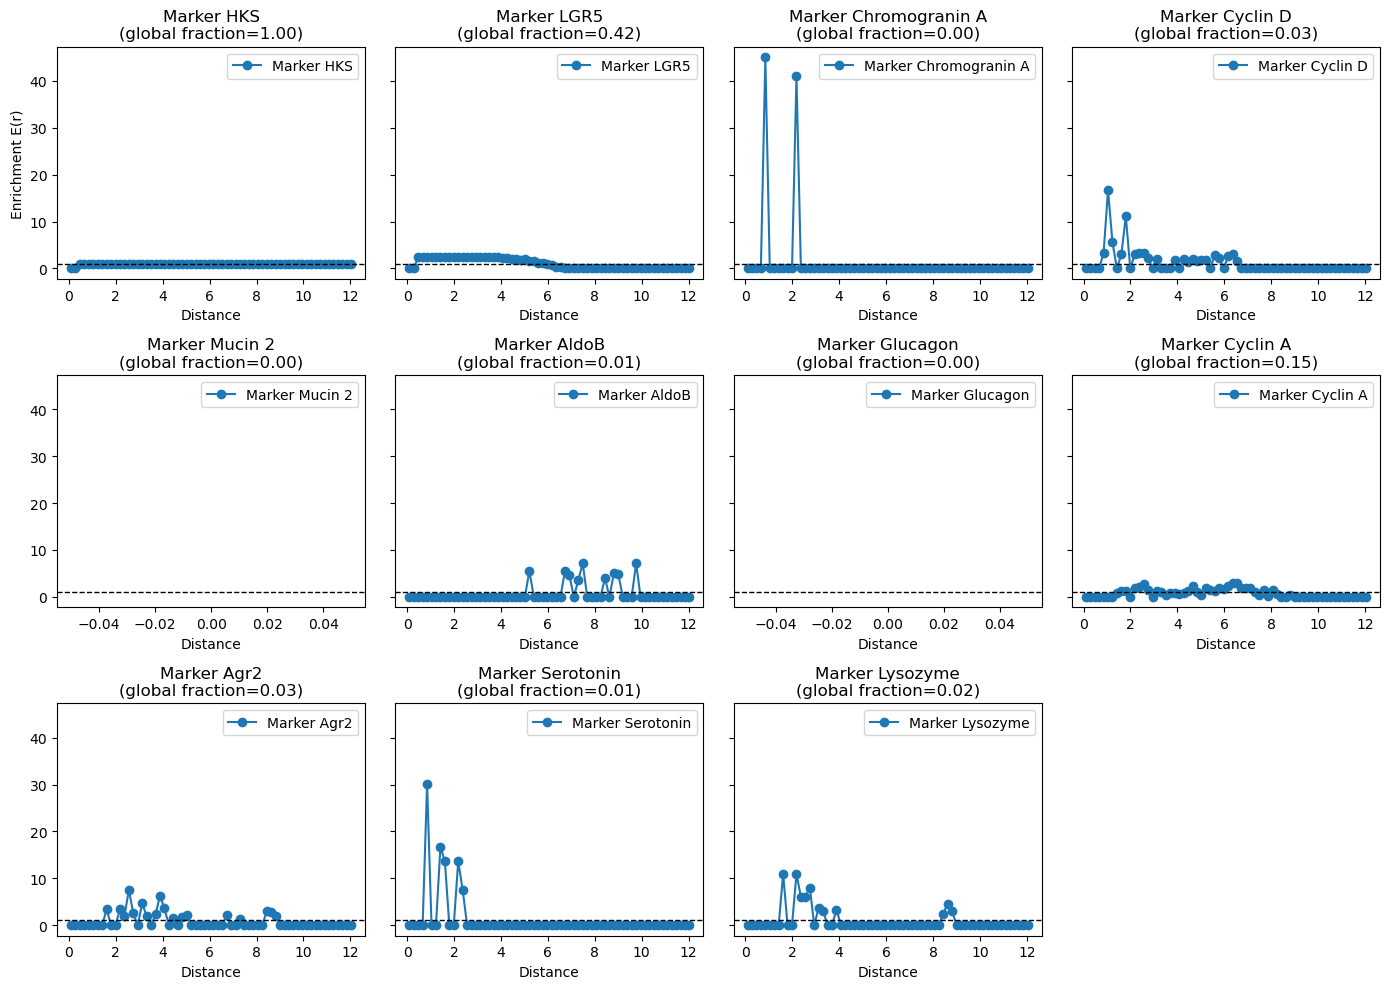

In [806]:
enrichment_lyso, f_local_lyso, f_global_lyso, bin_centers, Ns_lyso = binary_seed_enrichment(bins_dist_sources_lysozyme, positive_labels)

F = enrichment_lyso.shape[1]  # number of markers
nrows = int(np.ceil(F / 4))

fig, axes = plt.subplots(nrows, 4, figsize=(14, 10), sharey=True)
axes = axes.ravel()

for i in range(F):
    ax = axes[i]
    ax.plot(bin_centers, enrichment_lyso[:, i], marker="o", label=f"Marker {field_names[i]}")
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("Distance")
    if i == 0:
        ax.set_ylabel("Enrichment E(r)")
    ax.set_title(f"Marker {field_names[i]}\n(global fraction={f_global_lyso[i]:.2f})")
    ax.legend()

# hide unused axes
for j in range(F, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Graph

In [807]:
import numpy as np
import networkx as nx
import plotly.graph_objects as go

def remap_labels_to_contiguous(labels):
    """
    labels: (V,) int array, may contain negative -1 for unlabeled vertices.
    returns:
      labels_contig: (V,) ints in -1 or [0..C-1]
      mapping: dict old_label -> new_index
    """
    labs = np.asarray(labels)
    uniq = np.unique(labs[labs >= 0])
    mapping = {int(old): new for new, old in enumerate(uniq)}
    labels_contig = np.full_like(labs, -1)
    for old, new in mapping.items():
        labels_contig[labs == old] = new
    return labels_contig, mapping


def build_cell_graph(faces, vertex_cell_labels):
    """
    Build a cell adjacency graph from mesh faces and contiguous cell labels.

    Args
    ----
    faces : (F,3) ndarray of int
        Triangle mesh faces (indices into vertex array).
    vertex_cell_labels : (V,) ndarray of int
        Contiguous cell labels per vertex, in [0..C-1] or -1 for unlabeled.

    Returns
    -------
    G : networkx.Graph
        Undirected cell adjacency graph. Nodes are 0..C-1 (contiguous).
        Edge (i,j) exists if any face has vertices from both cells i and j.
    """
    G = nx.Graph()

    # only use vertices with valid cell labels
    labels = np.asarray(vertex_cell_labels, dtype=int)  # force int
    labels, _ = remap_labels_to_contiguous(labels)
    C = labels.max() + 1
    G.add_nodes_from(range(C))  # make sure we have 0..C-1 nodes

    for tri in faces:
        labs = labels[tri]
        labs = labs[labs >= 0]  # ignore unlabeled verts
        if len(labs) <= 1:
            continue
        uniq = np.unique(labs)
        if len(uniq) > 1:
            # add edges between all distinct cell labels in this face
            for i in range(len(uniq)):
                for j in range(i+1, len(uniq)):
                    G.add_edge(int(uniq[i]), int(uniq[j]))

    return G


def kNN_marker_composition(cell_graph, positive_labels, focal_marker_idx, k=3):
    """
    For cells positive for a given focal marker, compute the average composition
    of all markers among their k nearest neighbors.

    Args
    ----
    cell_graph : networkx.Graph
        Graph of cell adjacency (nodes = 0..N-1).
    positive_labels : (N, M) ndarray of {0,1}
        Binary marker positivity for each cell (N cells, M markers).
    focal_marker_idx : int
        Index of the focal marker (column in positive_labels).
    k : int
        Number of nearest neighbors to consider.

    Returns
    -------
    avg_comp : (M,) ndarray
        Mean fraction of neighbors positive for each marker.
    std_comp : (M,) ndarray
        Standard deviation across focal cells.
    sem_comp : (M,) ndarray
        Standard error of the mean across focal cells.
    comp_accum : (N_focal, M) ndarray
        Raw per-cell compositions (rows = focal cells, cols = markers).
    """
    N, M = positive_labels.shape
    focal_cells = np.where(positive_labels[:, focal_marker_idx] == 1)[0]
    if len(focal_cells) == 0:
        raise ValueError("No cells positive for the focal marker")

    # Precompute shortest-path distances
    sp_lengths = dict(nx.all_pairs_shortest_path_length(cell_graph))

    comp_accum = np.zeros((len(focal_cells), M), dtype=float)

    for idx, cell in enumerate(focal_cells):
        dists = sp_lengths[cell]
        neighbors_sorted = sorted(
            dists.items(),
            key=lambda x: x[1] if x[0] != cell else np.inf
        )
        k_neighbors = [n for n, d in neighbors_sorted[:k]]

        if len(k_neighbors) > 0:
            comp_accum[idx] = positive_labels[k_neighbors].mean(axis=0)

    # Average, spread, SEM
    avg_comp = comp_accum.mean(axis=0)
    std_comp = comp_accum.std(axis=0)
    sem_comp = std_comp / np.sqrt(len(focal_cells))

    return avg_comp, std_comp, sem_comp, comp_accum





def plot_cell_graph_3D(centroids, graph, node_color=None, node_size=5, edge_width=1):
    """
    Visualize a cell adjacency graph in 3D using centroids.

    Args
    ----
    centroids : (N,3) ndarray
        Coordinates of each cell (cell centers).
    graph : networkx.Graph
        Graph of cell adjacency (nodes = cell indices 0..N-1)
    node_color : (N,) array, optional
        Color per node (e.g., marker value or type)
    node_size : int, optional
        Marker size for nodes
    edge_width : int, optional
        Line width for edges
    """
    # Node coordinates
    x, y, z = centroids[:,0], centroids[:,1], centroids[:,2]

    if node_color is None:
        node_color = ['blue'] * len(centroids)
    else:
        # if node_color is numeric 0/1, map to colors
        if np.issubdtype(np.array(node_color).dtype, np.number):
            node_color = ['red' if val > 0 else 'blue' for val in node_color]

    # Node trace
    node_trace = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=node_size, color=node_color, line=dict(width=0)),
        hoverinfo='text'
    )

    # Create edge traces
    edge_x, edge_y, edge_z = [], [], []
    for i, j in graph.edges():
        edge_x += [centroids[i,0], centroids[j,0], None]
        edge_y += [centroids[i,1], centroids[j,1], None]
        edge_z += [centroids[i,2], centroids[j,2], None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(width=edge_width, color='gray'),
        hoverinfo='none'
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data'
    ))
    fig.show()

In [808]:
cell_graph = build_cell_graph(m.f, m.fields[:,0])

In [809]:
# Assume centroids is (C,3) and G is your cell graph
# For a binary marker:
marker_color = positive_labels[:,8]  # e.g., 0/1 for serotonin+
plot_cell_graph_3D(centroids, cell_graph, node_color=marker_color)

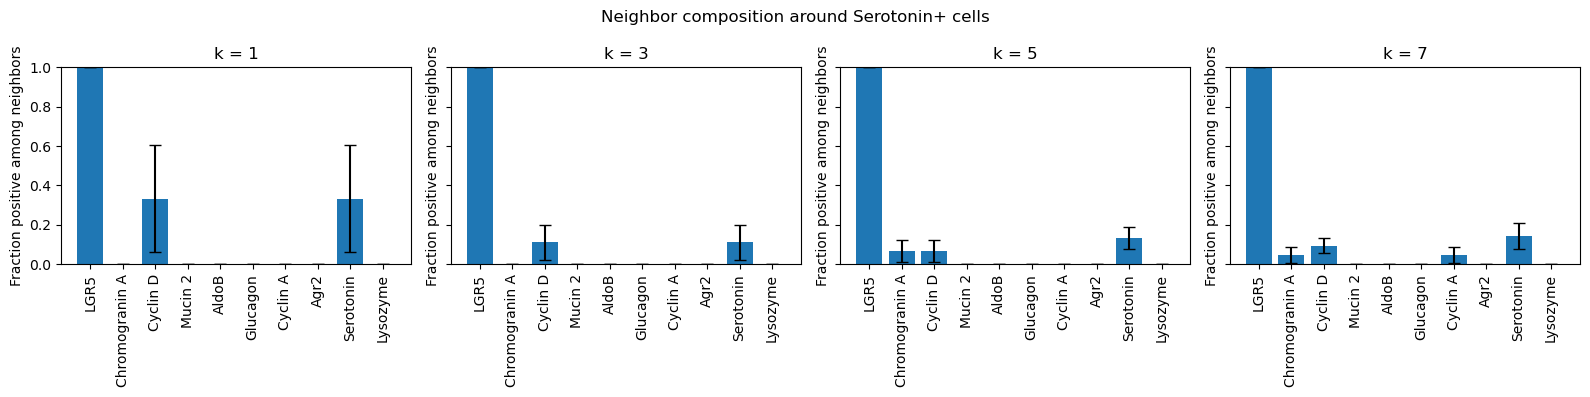

In [810]:
focal_marker_idx = 9  # serotonin (example)
k_values = [1, 3, 5, 7]

fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4), sharey=True)

for ax, k in zip(axes, k_values):
    avg_comp, std_comp, sem_comp, comp_accum = kNN_marker_composition(
        cell_graph, positive_labels, focal_marker_idx, k=k
    )
    ax.bar(range(len(field_names)-1), avg_comp[1:], yerr=sem_comp[1:], capsize=4)
    ax.set_xticks(range(len(field_names)-1))
    ax.set_xticklabels(field_names[1:], rotation=90)
    ax.set_ylim(0, 1)
    ax.set_title(f"k = {k}")
    ax.set_ylabel("Fraction positive among neighbors")

plt.suptitle(f"Neighbor composition around {field_names[focal_marker_idx]}+ cells")
plt.tight_layout()
plt.show()

In [811]:
def build_weight_matrix_from_graph(G, row_standardize=False):
    """
    Build NxN weight matrix W from networkx Graph G.
    Nodes in G may be arbitrary, so we create an index mapping.
    Returns (W, node_list) where node_list maps row index -> graph node.
    """
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    N = len(nodes)
    W = np.zeros((N, N), dtype=float)
    for u, v in G.edges():
        i, j = idx[u], idx[v]
        W[i, j] = 1.0
        W[j, i] = 1.0  # undirected
    if row_standardize:
        row_sums = W.sum(axis=1)
        # avoid divide-by-zero
        nz = row_sums != 0
        W[nz] = (W[nz].T / row_sums[nz]).T
    return W, nodes


def build_weight_matrix_kNN(G, k=1, row_standardize=False):
    """
    Build NxN weight matrix W from a cell adjacency graph G,
    considering up to k-nearest neighbors along the graph edges.

    Args
    ----
    G : networkx.Graph
        Undirected graph of cell adjacency (nodes can be arbitrary labels).
    k : int
        Number of nearest neighbors along graph edges to include.
        k=1 corresponds to direct neighbors (same as build_weight_matrix_from_graph()).
    row_standardize : bool
        If True, divide each row by its sum so rows sum to 1.

    Returns
    -------
    W : (N, N) ndarray
        Weight matrix of size N x N.
    node_list : list
        Maps row index -> graph node.
    """
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    N = len(nodes)
    W = np.zeros((N, N), dtype=float)

    # For each node, find neighbors up to k steps
    for n in nodes:
        visited = set([n])
        frontier = set([n])
        for step in range(k):
            next_frontier = set()
            for node in frontier:
                next_frontier.update(G.neighbors(node))
            next_frontier -= visited
            visited.update(next_frontier)
            frontier = next_frontier
            if not frontier:
                break
        visited.remove(n)  # exclude self
        i = idx[n]
        for neighbor in visited:
            j = idx[neighbor]
            W[i, j] = 1.0

    if row_standardize:
        row_sums = W.sum(axis=1)
        nz = row_sums != 0
        W[nz] = (W[nz].T / row_sums[nz]).T

    return W, nodes



def build_weight_matrix_distance(D, decay_length=1.0, row_standardize=False):
    """
    Build NxN weight matrix using exponentially decaying function of geodesic distance.

    Args
    ----
    D : (N, N) ndarray
        Symmetric distance matrix between cells.
    decay_length : float
        Characteristic distance lambda for exponential decay.
    row_standardize : bool
        Whether to row-normalize W.

    Returns
    -------
    W : (N, N) ndarray
        Weight matrix.
    """
    W = np.exp(-D / decay_length)
    np.fill_diagonal(W, 0.0)  # no self-weight

    if row_standardize:
        row_sums = W.sum(axis=1)
        nz = row_sums != 0
        W[nz] = (W[nz].T / row_sums[nz]).T

    return W


def compute_morans_I(X, W):
    """
    Compute global and local Moran's I for all markers.

    Args
    ----
    X : (N, M) ndarray
        Data matrix: N cells x M markers (binary or continuous).
    W : (N, N) ndarray
        Spatial weights matrix (binary adjacency or row-standardized).

    Returns
    -------
    global_I : (M,) ndarray
        Global Moran's I for each marker.
    local_I : (N, M) ndarray
        Local Moran's I values for each cell and marker.
    Z : (N, M) ndarray
        Mean-centered values (x - mean).
    m2 : (M,) ndarray
        Variance denominators for each marker.
    """
    N, M = X.shape
    x_mean = X.mean(axis=0)               # (M,)
    Z = X - x_mean                        # (N, M)
    denom = np.sum(Z**2, axis=0)          # (M,)
    S0 = W.sum()

    # Global Moran’s I
    num = np.sum(Z * (W @ Z), axis=0)     # (M,)
    global_I = (N / S0) * (num / denom)

    # Local Moran’s I
    m2 = denom / N
    WZ = W @ Z                            # (N, M)
    local_I = (Z / m2) * WZ               # (N, M)

    return global_I, local_I, Z, m2


def permutation_test_morans_I(X, W, n_perms=999, seed=None):
    """
    Permutation test for global Moran's I on all markers.

    Args
    ----
    X : (N, M) ndarray
        Data matrix: N cells x M markers (binary or continuous).
    W : (N, N) ndarray
        Spatial weights matrix (binary adjacency or row-standardized).
    n_perms : int
        Number of permutations.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    global_I_obs : (M,) ndarray
        Observed global Moran's I values for each marker.
    local_I_obs : (N, M) ndarray
        Observed local Moran's I values for each marker and cell.
    global_I_perm : (n_perms, M) ndarray
        Permuted global Moran's I values.
    p_values : (M,) ndarray
        Empirical p-values for global Moran's I.
    """
    rng = np.random.default_rng(seed)
    N, M = X.shape

    # observed values
    global_I_obs, local_I_obs, Z, m2 = compute_morans_I(X, W)

    # permuted values
    global_I_perm = np.zeros((n_perms, M))
    for p in range(n_perms):
        perm_idx = rng.permutation(N)
        X_perm = X[perm_idx, :]
        global_I_p, _, _, _ = compute_morans_I(X_perm, W)
        global_I_perm[p] = global_I_p

    # empirical p-values (two-sided)
    p_values = np.mean(np.abs(global_I_perm) >= np.abs(global_I_obs), axis=0)

    return global_I_obs, local_I_obs, global_I_perm, p_values

In [812]:
# 1. Identify markers with non-zero variance
valid_markers = positive_labels.var(axis=0) > 0
X_valid = positive_labels[:, valid_markers]
field_names_valid = [name for i, name in enumerate(field_names) if valid_markers[i]]

# 2. Build weight matrix from graph (unchanged)
W, nodes = build_weight_matrix_kNN(cell_graph, k=1, row_standardize=False)
# W, nodes = build_weight_matrix_from_graph(cell_graph, row_standardize=False)
# W = build_weight_matrix_distance(dist_heat, decay_length=2.0)


# 3. Run Moran’s I permutation test
global_I_obs, local_I_obs, global_I_perm, p_values = permutation_test_morans_I(
    X_valid, W, n_perms=999, seed=42
)


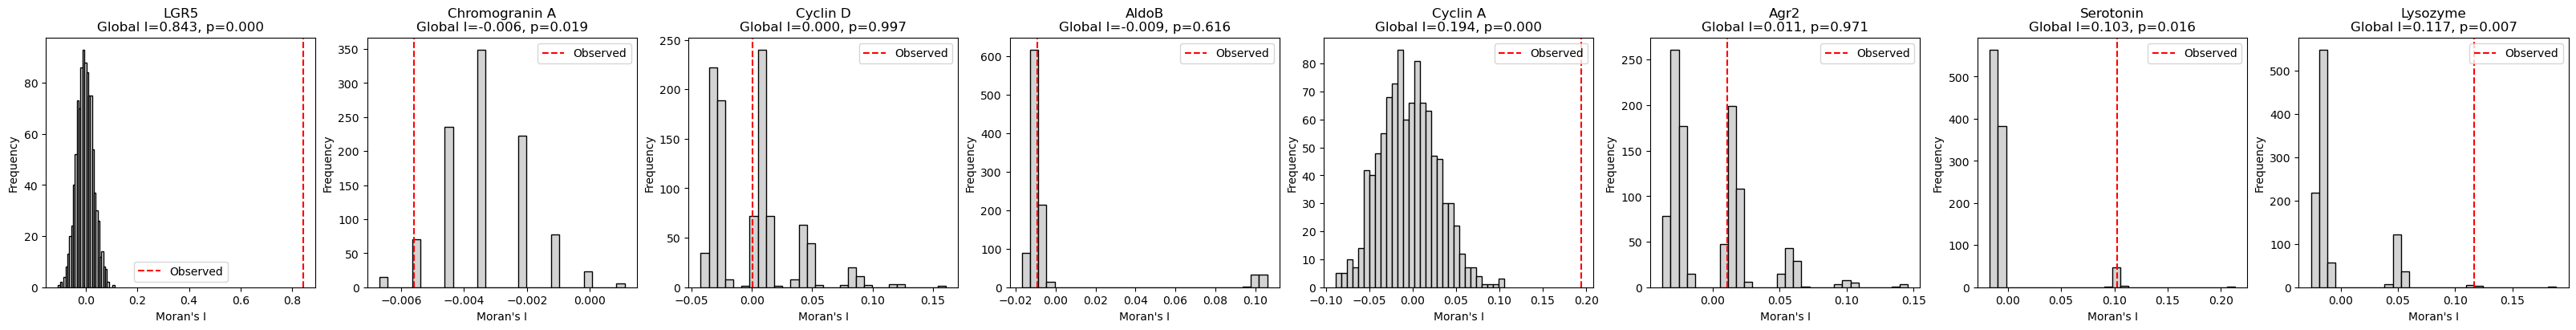

In [813]:

# 4. Plot global Moran’s I histograms with Matplotlib
M = X_valid.shape[1]
fig, axes = plt.subplots(1, M, figsize=(4*M, 4), constrained_layout=True)
if M == 1:
    axes = [axes]

for j in range(M):
    # mask NaNs if present
    perm_data = global_I_perm[:, j]
    perm_data = perm_data[~np.isnan(perm_data)]
    obs_value = global_I_obs[j]
    if len(perm_data) > 0:
        axes[j].hist(perm_data, bins=30, color="lightgray", edgecolor="black")
        axes[j].axvline(obs_value, color="red", linestyle="--", label="Observed")
    axes[j].set_title(f"{field_names_valid[j]}\nGlobal I={obs_value:.3f}, p={p_values[j]:.3f}")
    axes[j].set_xlabel("Moran's I")
    axes[j].set_ylabel("Frequency")
    axes[j].legend()

plt.show()


In [814]:

# 5. Plot local Moran’s I in 3D
for j, marker in enumerate(field_names_valid[:3]):  # first 3 valid markers
    node_color = local_I_obs[:, j]
    node_color = np.nan_to_num(node_color)  # replace NaN with 0 for plotting
    fig = go.Figure()
    edge_x, edge_y, edge_z = [], [], []
    for i, k in cell_graph.edges():
        edge_x += [centroids[i, 0], centroids[k, 0], None]
        edge_y += [centroids[i, 1], centroids[k, 1], None]
        edge_z += [centroids[i, 2], centroids[k, 2], None]
    edge_trace = go.Scatter3d(x=edge_x, y=edge_y, z=edge_z, mode='lines', line=dict(width=1, color='gray'))
    node_trace = go.Scatter3d(
        x=centroids[:, 0], y=centroids[:, 1], z=centroids[:, 2],
        mode='markers',
        marker=dict(size=5, color=node_color, colorscale='RdBu', colorbar=dict(title=f"Local Moran's I ({marker})")),
        text=[f"Cell {i}" for i in range(len(centroids))], hoverinfo='text'
    )
    fig.add_trace(edge_trace)
    fig.add_trace(node_trace)
    fig.update_layout(title=f"Local Moran's I for {marker}", scene=dict(aspectmode='data'))
    fig.show()


In [815]:
def compute_cross_morans_I(X, Y, W):
    """
    Compute global and local cross-Moran's I for all marker pairs.

    Args
    ----
    X : (N, M) ndarray
        First set of markers (e.g., binary 0/1), shape: N cells x M markers.
    Y : (N, M) ndarray
        Second set of markers, same shape as X.
    W : (N, N) ndarray
        Spatial weights matrix (binary adjacency or row-standardized).

    Returns
    -------
    global_I : (M, M) ndarray
        Global cross-Moran's I between each pair of markers X[:,i] and Y[:,j].
    local_I : (N, M, M) ndarray
        Local cross-Moran's I for each cell i and marker pair (X[:,i], Y[:,j]).
    Z_X : (N, M) ndarray
        Mean-centered X values.
    Z_Y : (N, M) ndarray
        Mean-centered Y values.
    m2_X : (M,) ndarray
        Variance denominators for X markers.
    """
    N, M = X.shape
    x_mean = X.mean(axis=0)
    y_mean = Y.mean(axis=0)
    Z_X = X - x_mean
    Z_Y = Y - y_mean

    m2_X = np.sum(Z_X**2, axis=0) / N  # variance per marker

    S0 = W.sum()

    # Global cross-Moran's I
    # Result shape (M, M) for all X_i vs Y_j pairs
    num = Z_X.T @ W @ Z_Y  # (M, M)
    global_I = (N / S0) * (num / np.sum(Z_X**2, axis=0)[:, None])

    # Local cross-Moran's I
    # WZ_Y: weighted sum of neighbors' Y values
    WZ_Y = W @ Z_Y  # (N, M)
    # Broadcast: (N, M, M) = (N, M_X, M_Y)
    local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]  

    return global_I, local_I, Z_X, Z_Y, m2_X


def permutation_test_cross_morans_I(X, Y, W, n_perms=999, seed=None):
    """
    Permutation test for global cross-Moran's I on all marker pairs.

    Args
    ----
    X : (N, M) ndarray
        First set of markers.
    Y : (N, M) ndarray
        Second set of markers.
    W : (N, N) ndarray
        Spatial weights matrix.
    n_perms : int
        Number of permutations.
    seed : int, optional
        Random seed.

    Returns
    -------
    global_I_obs : (M, M) ndarray
        Observed global cross-Moran's I for each marker pair.
    local_I_obs : (N, M, M) ndarray
        Observed local cross-Moran's I.
    global_I_perm : (n_perms, M, M) ndarray
        Permuted global I values.
    p_values : (M, M) ndarray
        Empirical p-values for global cross-Moran's I.
    """
    rng = np.random.default_rng(seed)
    N, M = X.shape

    # Observed values
    global_I_obs, local_I_obs, _, _, _ = compute_cross_morans_I(X, Y, W)

    # Permuted values
    global_I_perm = np.zeros((n_perms, M, M))
    for p in range(n_perms):
        perm_idx = rng.permutation(N)
        Y_perm = Y[perm_idx, :]  # shuffle Y values across cells
        global_I_p, _, _, _, _ = compute_cross_morans_I(X, Y_perm, W)
        global_I_perm[p] = global_I_p

    # Empirical two-sided p-values
    p_values = np.mean(np.abs(global_I_perm) >= np.abs(global_I_obs)[None, :, :], axis=0)

    return global_I_obs, local_I_obs, global_I_perm, p_values


In [816]:
# === 2. Filter markers if needed ===
# Use all positive_labels markers
X = positive_labels  # shape (N_cells, N_markers)
field_names_valid = field_names  # list of marker names


In [817]:

# === 3. Compute cross-Moran's I with permutations ===
n_perms = 999
global_I_obs, local_I_obs, global_I_perm, p_values = permutation_test_cross_morans_I(
    X, X, W, n_perms=n_perms, seed=42
)


/tmp/ipykernel_1194040/1066273054.py:40: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_1194040/1066273054.py:46: RuntimeWarning:

invalid value encountered in divide



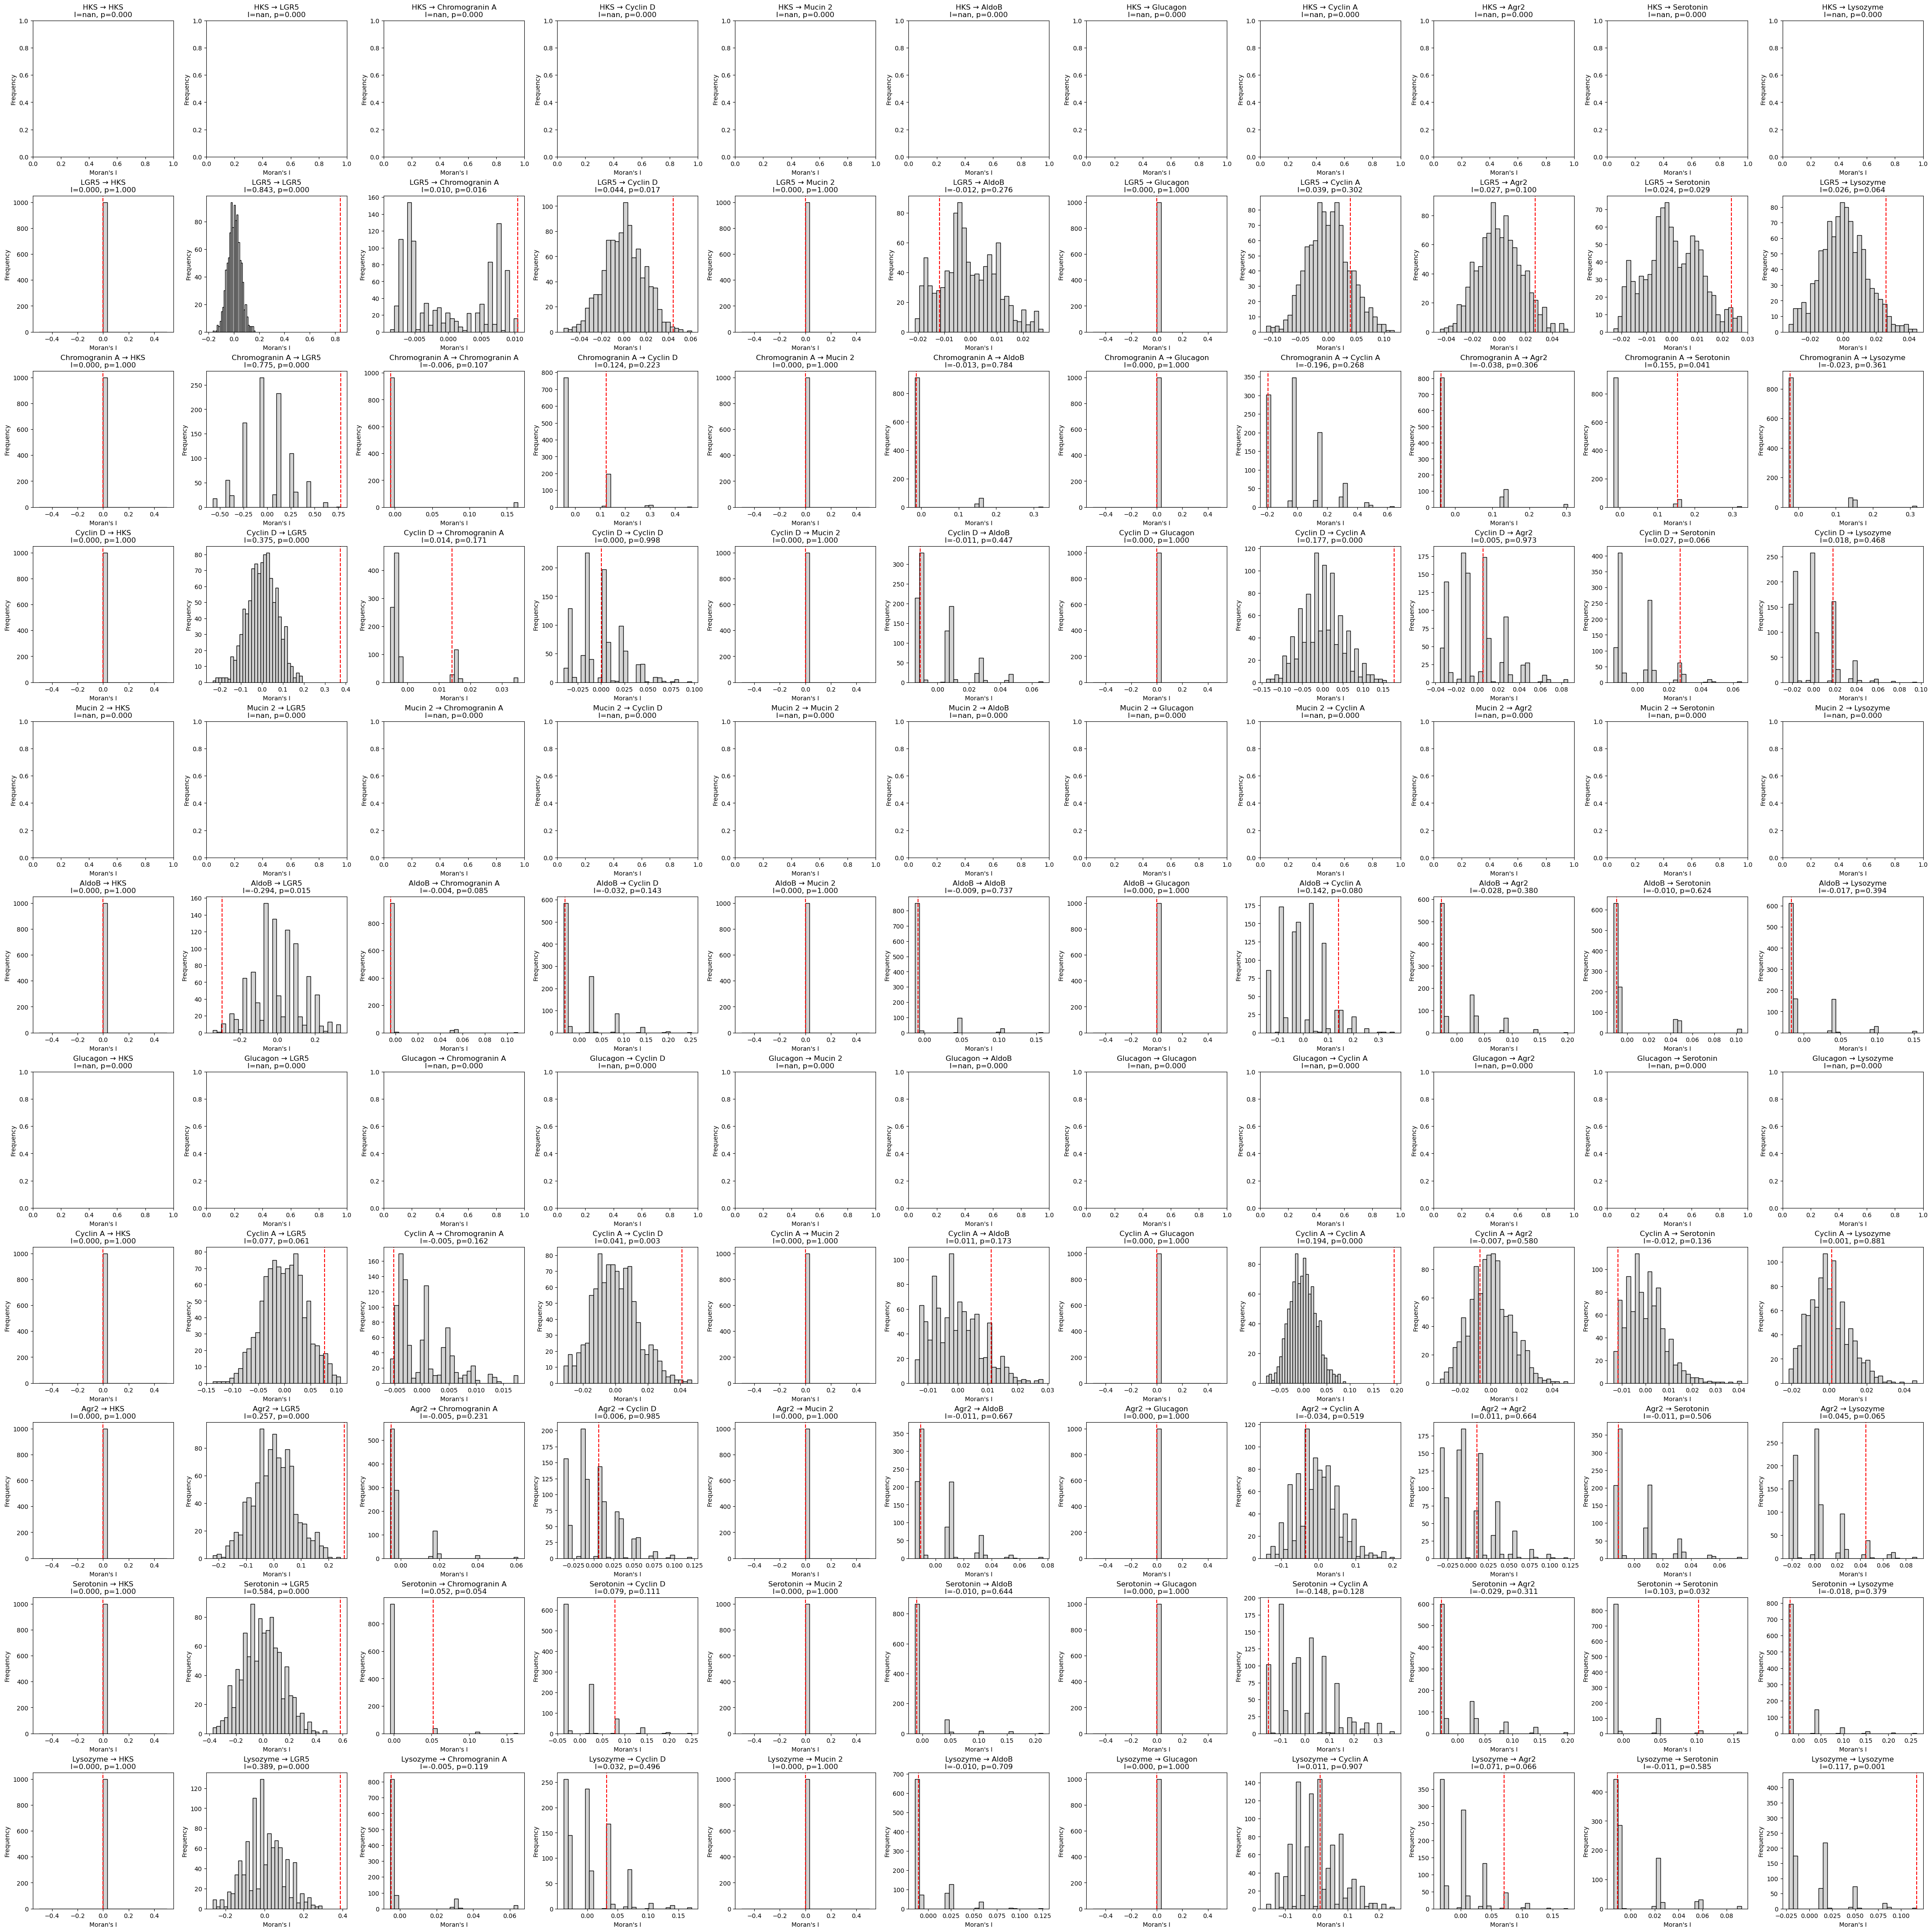

In [818]:

# === 4. Plot global cross-Moran's I ===
M = X.shape[1]
fig, axes = plt.subplots(M, M, figsize=(4*M, 4*M), constrained_layout=True)
for i in range(M):
    for j in range(M):
        ax = axes[i, j] if M > 1 else axes
        perm_data = global_I_perm[:, i, j]
        perm_data = perm_data[~np.isnan(perm_data)]
        obs_value = global_I_obs[i, j]
        if len(perm_data) > 0:
            ax.hist(perm_data, bins=30, color="lightgray", edgecolor="black")
            ax.axvline(obs_value, color="red", linestyle="--")
        ax.set_title(f"{field_names_valid[i]} → {field_names_valid[j]}\nI={obs_value:.3f}, p={p_values[i,j]:.3f}")
        ax.set_xlabel("Moran's I")
        ax.set_ylabel("Frequency")
plt.show()
